In [1]:
%load_ext autoreload
%autoreload 2

# Set-up: packages and local utilities used throughout this notebook.
# Core numerical + local MCMC utilities for the AD toy model.
import MCMC_Sampliers_Testing as MCMCsmp
import Utilities as Utils

# Numerical elements
# from numpy.linalg import norm
import numpy as np
# from numpy import dot, array, transpose, diag
# import random
# import math

# Input/output utilities
import os
# import pandas as pd

# Stats elements
# from scipy.stats import chi2
rng = np.random.default_rng()

# Plotting support
# from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt

# Finished message utilities (optional)
# import smtplib
# from email.message import EmailMessage

from functools import partial
# import multiprocessing as mp

# Save locations (change to your local machine paths).
# MacbookPro
saveLocBase = "/Users/guillers/Documents/GitHub/multiproposal/estimations/" 
saveLocBaseData = "/Users/guillers/Documents/GitHub/multiproposal/data/"

# # Ubuntu Work Machine
# saveLocBase = "/home/neghadmin/Dropbox/MCMC_Runs/"
# saveLocBaseData = "/home/neghadmin/Dropbox/MCMC_Runs/Data/"


In [2]:
# Experiment C3: set-up (small dimension example)
expIdC3 = 1 # Experiment ID

# Model dimension and parameter space size
ThetaDmExC3 = 11 # d
NumParmsC3 = int(ThetaDmExC3*(ThetaDmExC3 -1)/2) # m
print(f"d (nr of modes) = {ThetaDmExC3}, m (nr of parameters) = {NumParmsC3}")

# Observation location (last few components)
ObsScaleC3 = 7 # d_0?

kapExC3 = 0.1 # Diffusivity parameter kappa in (A + kI)
sigExC3 = 0.1 # Observation noise scale



d (nr of modes) = 11, m (nr of parameters) = 55


CovPriorC3diag.shape = (55,), first 5 entries = [0.0625     0.01234568 0.00390625 0.0016     0.0007716 ]


Text(0.5, 1.0, 'Diagonal Prior Covariance Matrix')

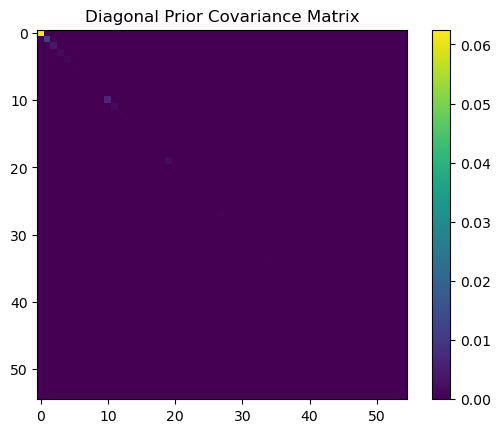

In [3]:
# Build structural diagonal prior for the upper-triangular parameters a_ij.
# Var(A_ij) = tau2 * a_i^2 * a_j^2 * omega(|i-j|) with power-law decay.
iju = np.triu_indices(ThetaDmExC3, k=1)
i = iju[0].astype(float) # row indices of upper-triangular entries
j = iju[1].astype(float) # column indices of upper-triangular entries
r = np.abs(iju[0] - iju[1]) 
optional_robustness = 1 # added to r because Python indexes start at 0
tau2 = 1.0 # overall scale of the prior variance
alpha = 1.0 # penalizes interactions involving higher-index modes 
gamma = 2.0 # penalizes long-range interactions 
a_i = (optional_robustness + i)**(-alpha)
a_j = (optional_robustness+ j)**(-alpha)
omega = (optional_robustness + r)**(-gamma)
CovPriorC3diag = tau2 * (a_i**2) * (a_j**2) * omega
CovPriorC3 = np.diag(CovPriorC3diag)
print(f"CovPriorC3diag.shape = {CovPriorC3diag.shape}, first 5 entries = {CovPriorC3diag[:5]}")
plt.imshow(CovPriorC3, cmap='viridis')
plt.colorbar()
plt.title("Diagonal Prior Covariance Matrix")

Text(0.5, 1.0, 'Nearest-Neighbor Skew Matrix A*')

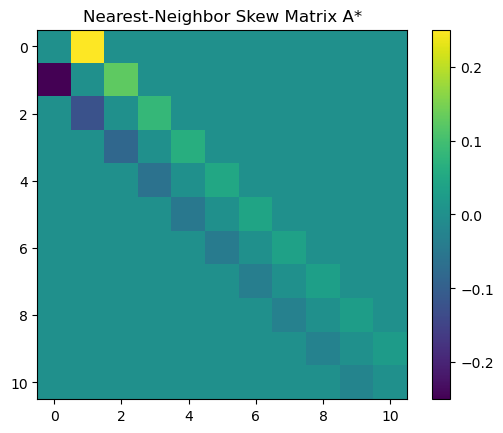

In [4]:
# Build a nearest-neighbor skew matrix A* to generate synthetic data.
w = Utils.make_omegas_power(ThetaDmExC3, beta=alpha, c=2.0**(-gamma), offset=1.0)
A_star_C3 = Utils.make_Astar_nn(ThetaDmExC3, w)
plt.imshow(A_star_C3, cmap='viridis')
plt.colorbar()
plt.title("Nearest-Neighbor Skew Matrix A*")

In [5]:
# Build a true matrix A* to generate synthetic data  by sampling from the prior (inverse crime)
# A_star_C3 = Utils.make_Astar_prior()

# should use this code
# q0gen = lambda: np.random.multivariate_normal(np.zeros(NumParmsC3), CovPriorC3)

In [6]:
# Source term g = e1 (energy injected at largest scale).
gvecExC3 = np.zeros(ThetaDmExC3)
gvecExC3[0] = 1.0

# Solve for theta using the true A* and source g.
theta_tr_ExC3 = Utils.getThA(ThetaDmExC3, Utils.Apar_from_A(A_star_C3), gvecExC3, kapExC3)
print(theta_tr_ExC3)


[2.44636338e+00 3.02145465e+00 2.47556305e+00 1.56150631e+00
 8.02340642e-01 3.47201601e-01 1.29524929e-01 4.23987336e-02
 1.23525424e-02 3.22942284e-03 8.07355710e-04]


In [7]:

# Partial observation window P(theta) = theta[d0-k : d0].
dataslideStC3 = ObsScaleC3 - 3
dataslideEndC3 = ObsScaleC3 - 1
zExC3 = theta_tr_ExC3[dataslideStC3:dataslideEndC3]
print(zExC3)


[0.80234064 0.3472016 ]


In [8]:
# Saving configurations and results (change paths as needed).
ExpDir = "Test_Problems/Experiment_C/" + "Ex_ID_"+ str(expIdC3) + "/"
FileNmBase = saveLocBase+ExpDir
FileNmBaseData =saveLocBaseData+ExpDir

os.makedirs(FileNmBase, exist_ok=True)
os.makedirs(FileNmBaseData, exist_ok=True)


In [9]:

# Indices of components to track in trace/hist plots.
comps = [0,1,2,Utils.ij_to_k(0,ThetaDmExC3 -1, ThetaDmExC3),Utils.ij_to_k(ObsScaleC3-1,ObsScaleC3, ThetaDmExC3), Utils.ij_to_k(ObsScaleC3-1,ObsScaleC3+1,ThetaDmExC3) ,NumParmsC3-2,NumParmsC3-1]

print("components =", comps)
print("max component =", max(comps))


components = [0, 1, 2, 9, 45, 46, 53, 54]
max component = 54


## MCMC

In [16]:
# Multiproposal pCN configuration
rho = .95
pMP = 10

# Chain configuration
chainLn = 10000
burn_In = 1000
thin = 1
numChain = 1

# Choose sampler variant
# MC_meth = MCMCsmp.locMpCNMTM_DATA # multiple-try localized multiproposal pCN
# MCMC_type = "mpcN MTM Loc"
MC_meth = MCMCsmp.MpCN_DATA # multiproposal pCN
MCMC_type = "mpCN"

In [17]:
# Potential for partial observations using a contiguous slice of theta.
PotC3 = partial(Utils.PotExAD_slice, gvec=gvecExC3, sig=sigExC3, ModDm=ThetaDmExC3, z=zExC3, kap=kapExC3, data_st= dataslideStC3, data_end = dataslideEndC3, mode = "soft")
MC_arg = [NumParmsC3,CovPriorC3,rho,PotC3,pMP]
MC_arg

[55,
 array([[6.25000000e-02, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 1.23456790e-02, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 3.90625000e-03, ...,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        ...,
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         3.08641975e-05, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 1.13367117e-05, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
         0.00000000e+00, 0.00000000e+00, 2.06611570e-05]], shape=(55, 55)),
 0.95,
 functools.partial(<function PotExAD_slice at 0x156dad760>, gvec=array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]), sig=0.1, ModDm=11, z=array([0.80234064, 0.3472016 ]), kap=0.1, data_st=4, data_end=6, mode='soft'),
 10]

In [18]:
# Initial state generator from the Gaussian prior on parameters.
q0gen = lambda: np.random.multivariate_normal(np.zeros(NumParmsC3), CovPriorC3)

# Run chains in parallel and collect samples/potentials.
MCMC_Chains, MCMC_Pot, AR = Utils.parallel_MCMC_Runs_Data(chainLn,numChain,MC_meth,MC_arg, q0gen, burn_In, thin, max_workers=1)
print(AR)


Total MCMC Runs: 1


Parallel MCMC Runs:   0%|          | 0/1 [00:00<?, ?it/s]

0.64


Number of samples available: 9001


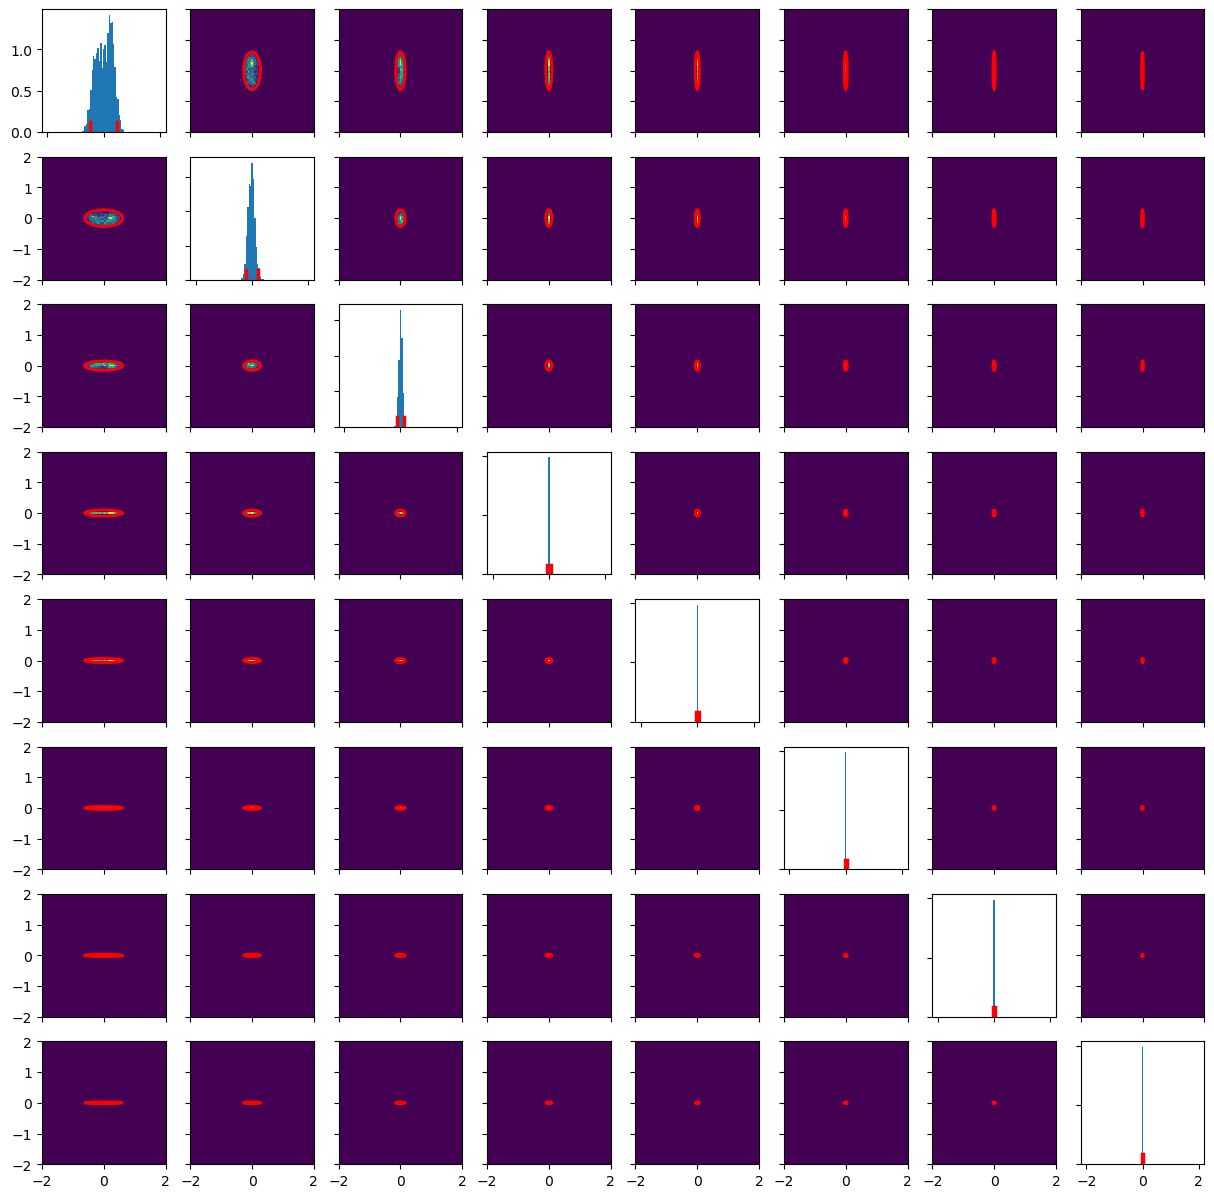

In [19]:

# Persist results and quick diagnostics.
Utils.writeCSV(FileNmBaseData+"exploratory_MCMC_run.csv", MCMC_Chains)
Utils.writeCSV(FileNmBaseData+"exploratory_MCMC_run_Pot.csv", MCMC_Pot)

Utils.plot_timeseries(MCMC_Chains, MCMC_Pot, comps, FileNmBase + "timeseries.png", MCMC_type, burn_In)

numStationarySamps= MCMC_Chains.shape[0]
print("Number of samples available: " + str(numStationarySamps))

histFileNm = FileNmBase + "Baseline_Histogram.png"
R = 2* tau2
dr= tau2/20
#GridComps = [0,1, ThetaDmExC3, ThetaDmExC3+1, NumParmsC3 -2, NumParmsC3 -1]
Utils.makeHistGrid_Comps(R, dr, MCMC_Chains,comps ,histFileNm, C=CovPriorC3, beta=0.95, hidePlt = False)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


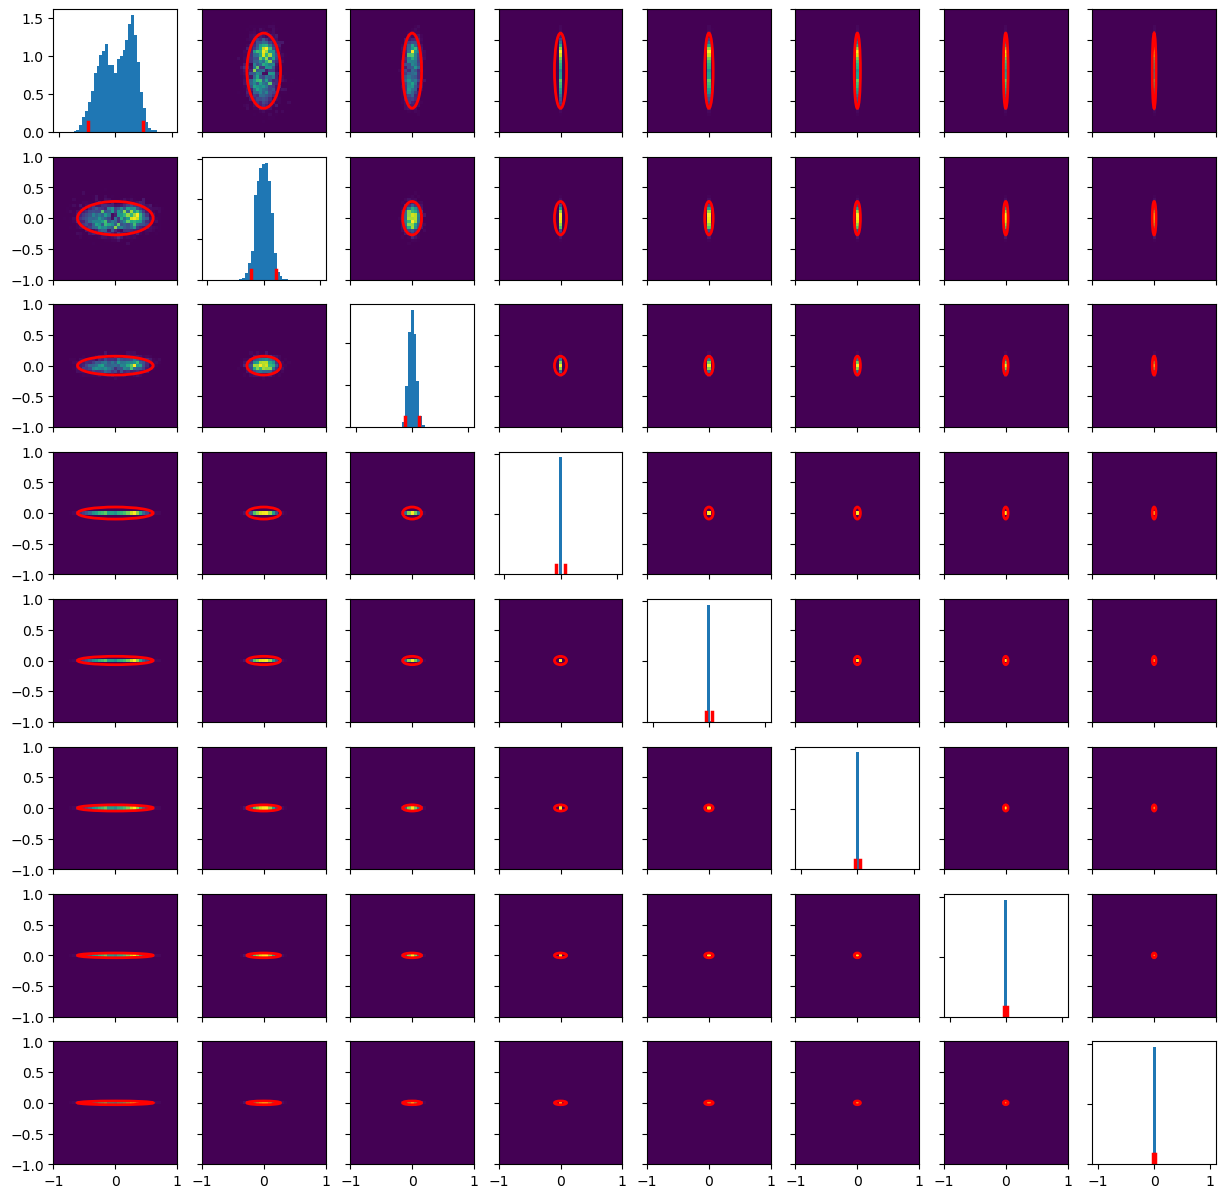

In [14]:
%load_ext autoreload
%autoreload 2

# Rebuild the histogram with a smaller plotting radius.
histFileNm = FileNmBase + "Baseline_Histogram.png"
R = tau2
dr= tau2/20
#GridComps = [0,1, ThetaDmExC3, ThetaDmExC3+1, NumParmsC3 -2, NumParmsC3 -1]
Utils.makeHistGrid_Comps(R, dr, MCMC_Chains,comps ,histFileNm, C=CovPriorC3, beta=0.95, hidePlt = False)

In [15]:
# # Experiment C3: set-up (larger dimension example)
# expIdC3 = 2 # Experiment ID

# # Model dimension and parameter space size
# ThetaDmExC3 = 25
# NumParmsC3 = int(ThetaDmExC3*(ThetaDmExC3 -1)/2)

# # Observation location (last few components)
# ObsScaleC3 = 10

# kapExC3 = 0.1 # Diffusivity parameter kappa in (A + kI)
# sigExC3 = 0.1 # Observation noise scale

# # Build structural diagonal prior for the upper-triangular parameters a_ij.
# # Var(A_ij) = tau2 * a_i^2 * a_j^2 * omega(|i-j|) with power-law decay.
# iju = np.triu_indices(ThetaDmExC3, k=1)
# i = iju[0].astype(float)
# j = iju[1].astype(float)
# r = np.abs(iju[0] - iju[1])

# gamma = 2.0
# alpha = 1.0
# omega = (1.0 + r)**(-gamma)
# a_i = (1.0 + i)**(-alpha)
# a_j = (1.0 + j)**(-alpha)

# tau2 = 1.0
# CovPriorC3diag = tau2 * (a_i**2) * (a_j**2) * omega

# CovPriorC3 = np.diag(CovPriorC3diag)

# # Build a nearest-neighbor skew matrix A* to generate synthetic data.
# w = Utils.make_omegas_power(ThetaDmExC3, beta=alpha, c=2.0**(-gamma), offset=1.0)
# A_star_C3 = Utils.make_Astar_nn(ThetaDmExC3, w)

# # Source term g = e1 (energy injected at largest scale).
# gvecExC3 = np.zeros(ThetaDmExC3)
# gvecExC3[0] = 1.0
# theta_tr_ExC3 = Utils.getThA(ThetaDmExC3, Utils.Apar_from_A(A_star_C3), gvecExC3, kapExC3)
# print(theta_tr_ExC3)

# # Partial observation window P(theta) = theta[d0-k : d0].
# dataslideStC3 = ObsScaleC3 - 3
# dataslideEndC3 = ObsScaleC3 -1

# zExC3 = theta_tr_ExC3[dataslideStC3:dataslideEndC3]
# print(zExC3)

# ExpDir = "Test_Problems/Experiment_C/" + "Ex_ID_"+ str(expIdC3) + "/"
# FileNmBase = saveLocBase+ExpDir
# FileNmBaseData =saveLocBaseData+ExpDir

# os.makedirs(FileNmBase, exist_ok=True)
# os.makedirs(FileNmBaseData, exist_ok=True)

# # Indices of components to track in trace/hist plots.
# comps = [0,1,2,Utils.ij_to_k(0,ThetaDmExC3 -1, ThetaDmExC3),Utils.ij_to_k(ObsScaleC3-1,ObsScaleC3, ThetaDmExC3), Utils.ij_to_k(ObsScaleC3-1,ObsScaleC3+1,ThetaDmExC3) ,NumParmsC3-2,NumParmsC3-1]

# print("components =", comps)
# print("max component =", max(comps))
